## Loading Data

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gen_mean_std = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/real_samples.npz')

# gen_mean_std = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep_wildfire_results/depth_8_epochs_20000_schedule_VE_sigma_2/generated_mean_std.npz')
# gen_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep_wildfire_results/depth_8_epochs_20000_schedule_VE_sigma_2/generated_samples.npz')
# real_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep_wildfire_results/depth_8_epochs_20000_schedule_VE_sigma_2/real_samples.npz')

# gen_mean_std = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep2_wildfire_results/depth_8_epochs_30000_schedule_VE_sigma_2/generated_mean_std.npz')
# gen_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep2_wildfire_results/depth_8_epochs_30000_schedule_VE_sigma_2/generated_samples.npz')
# real_samples = np.load('/Users/isaaclee/Wildfire_Research/recursive_deep2_wildfire_results/depth_8_epochs_30000_schedule_VE_sigma_2/real_samples.npz')

training_data = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_train_data_norm.npy')
testing_data = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_test_data_norm.npy')

pred_means = gen_mean_std['array1']
pred_stds = gen_mean_std['array2']
dist_samples = gen_samples['arr_0']
real_samples = real_samples['arr_0']

print(pred_means.shape)
print(pred_stds.shape)
print(dist_samples.shape)
print(real_samples.shape)

print(training_data.shape)
print(testing_data.shape)

(1200, 3)
(1200, 3)
(1200000, 3)
(1200, 3)
(14000, 27)
(1200, 27)


## Undoing Normalization

In [64]:
from scipy.stats import norm

x3_min = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_min.npy')
x3_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_max.npy')
x3_first_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/first_x3_max.npy')

x3_pred = pred_means[:,2]
x3_new = x3_pred * (x3_max - x3_min) + x3_min
x3 = norm.cdf(x3_new) * x3_first_max

pred_means[:,2] = x3

# Unnormalizing real values

real_x3 = real_samples[:,2]
real_x3_new = real_x3 * (x3_max - x3_min) + x3_min
real_x3_orig = norm.cdf(real_x3_new) * x3_first_max

real_samples[:,2] = real_x3_orig

## Undoing normalization for pred distributions and calculating std

In [65]:
print(dist_samples.shape)

dist_x3 = dist_samples[:,2]
dist_x3_new = dist_x3 * (x3_max - x3_min) + x3_min
dist_x3_orig = norm.cdf(dist_x3_new) * x3_first_max

dist_samples[:,2] = dist_x3_orig
dist_x3_orig = dist_x3_orig.reshape(1200,1000)

print(dist_x3_orig.shape)

std_x3 = np.std(dist_x3_orig, axis=1)

print(std_x3.shape)


(1200000, 3)
(1200, 1000)
(1200,)


## x3 analysis

In [66]:
real = real_samples[:,2]
pred = pred_means[:,2]

print("NORM.PPF/CDF METRICS")
print("="*50)

mape = np.mean(np.abs(real - pred) / real)
print(f"MAPE: {mape}")

mdape = np.median(np.abs(real-pred)/real)
print(f"MdAPE: {mdape}")

within_1_std = np.abs(real-pred) <= std_x3
proportions = within_1_std.astype(int)
print(f'Withind 1 std: {np.mean(proportions)}')

print(f'Standard deviation: {np.mean(std_x3)}')

NORM.PPF/CDF METRICS
MAPE: 0.6216146882202122
MdAPE: 0.45792667504730095
Withind 1 std: 0.3233333333333333
Standard deviation: 98.9938773137866


In [67]:
tp = 0
fp = 0
fn = 0

for i in range(1200):
    tp += min(real[i], pred[i])
    if real[i] < pred[i]:
        fp += np.abs(real[i]-pred[i])
    else:
        fn += np.abs(real[i]-pred[i])

sc = 2*tp / (2*tp + fn + fp)
print(f"Sorensens: {sc}")

Sorensens: 0.7358881875453296


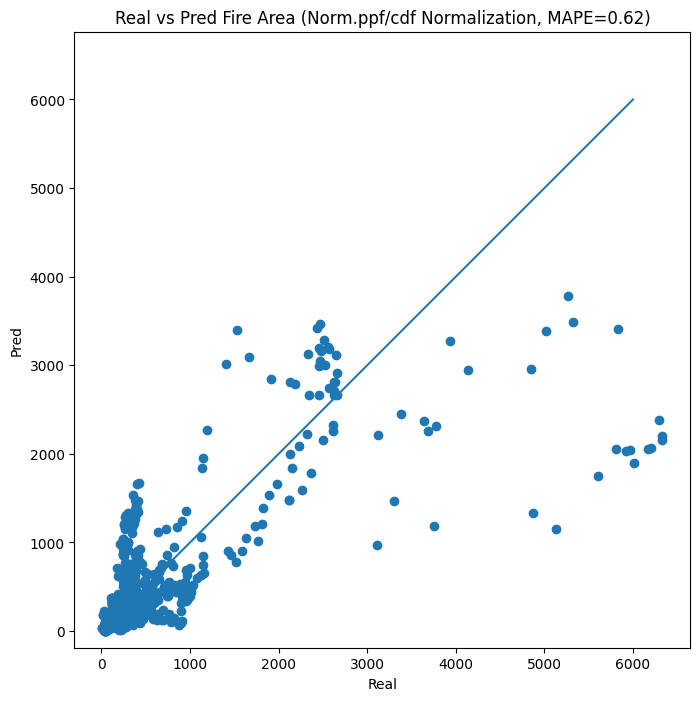

In [68]:
plt.figure(figsize=(8,8))
plt.scatter(real, pred)
x=np.linspace(0,6000, 6000)
plt.axis("square")
plt.plot(x,x)
# plt.xlim(0,3000)
# plt.ylim(0,3000)
plt.title('Real vs Pred Fire Area (Norm.ppf/cdf Normalization, MAPE=0.62)')
plt.xlabel('Real')
plt.ylabel('Pred')
plt.show()

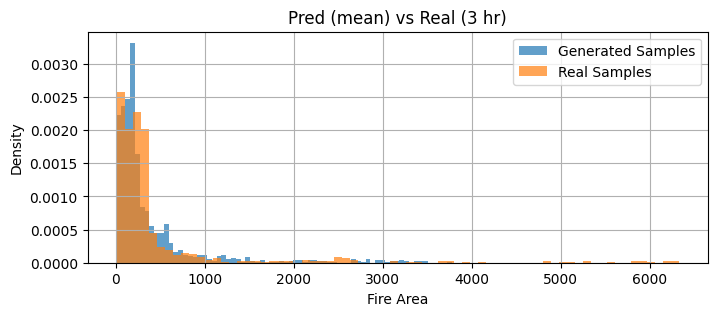

In [69]:
plt.figure(figsize=(8,3))
plt.title('Pred (mean) vs Real (3 hr)')
plt.hist(pred, bins='auto', alpha=0.7, label='Generated Samples', density=True)
plt.hist(real, bins='auto', alpha=0.7, label='Real Samples', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.ylabel('Density')
plt.grid(True)
plt.show()

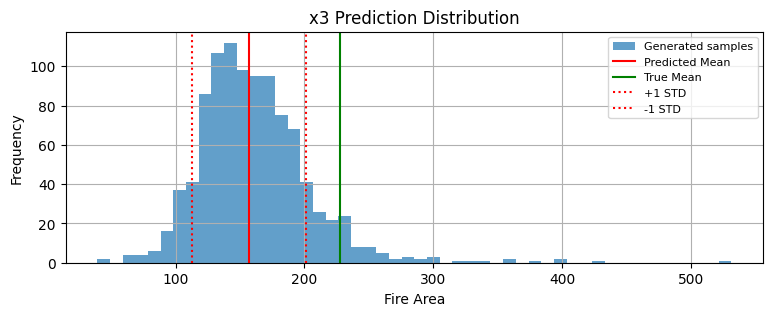

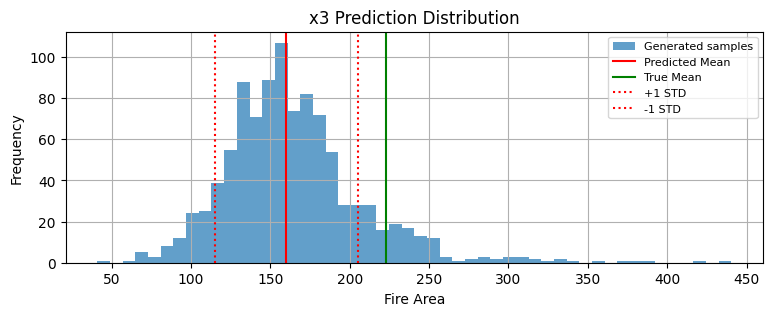

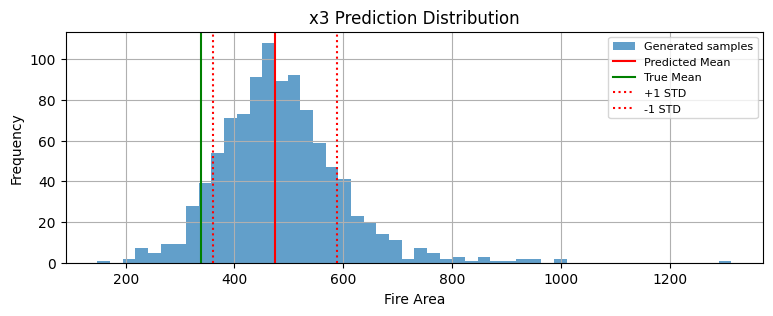

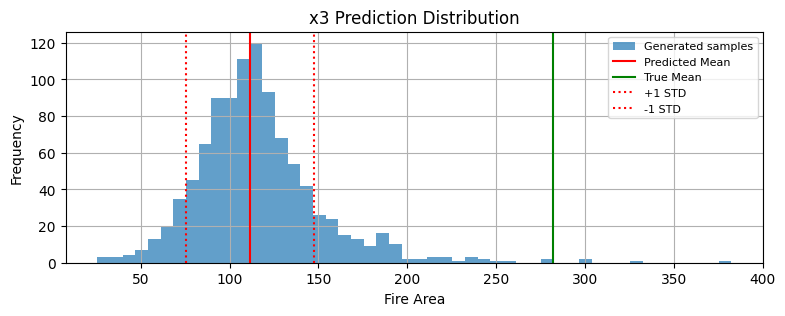

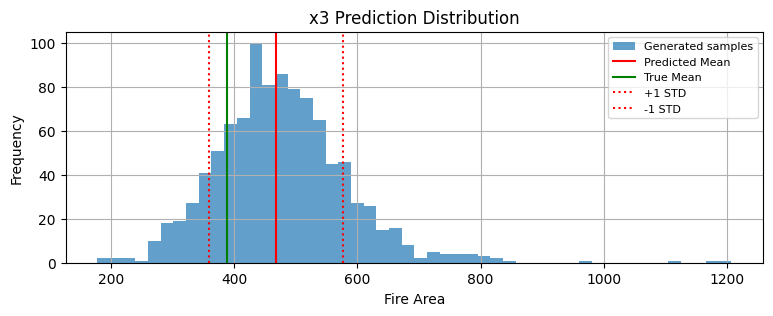

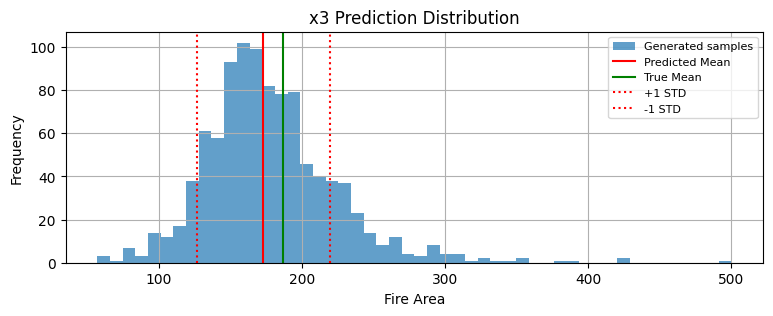

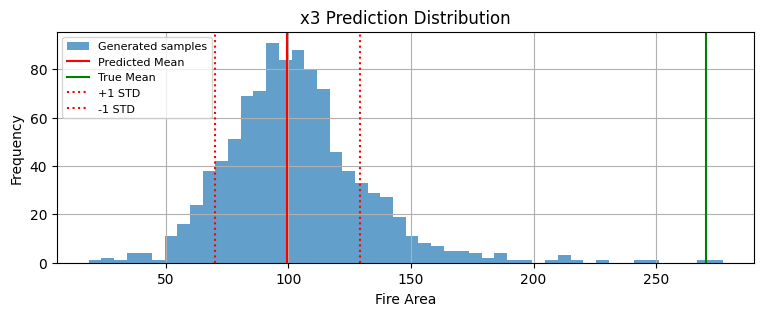

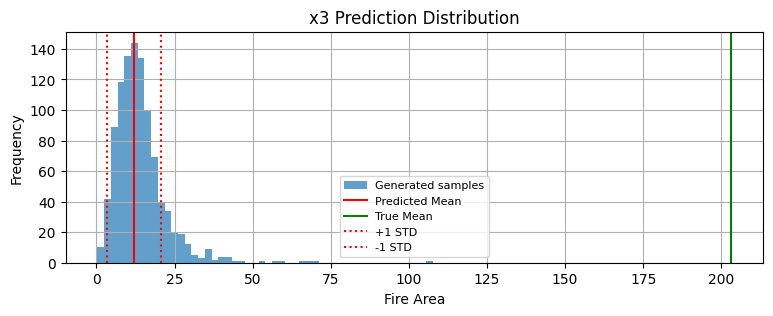

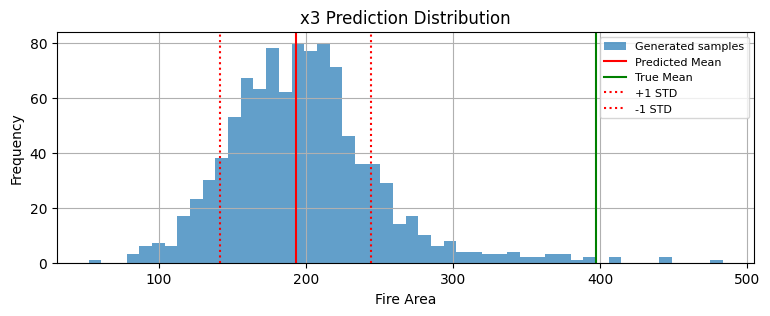

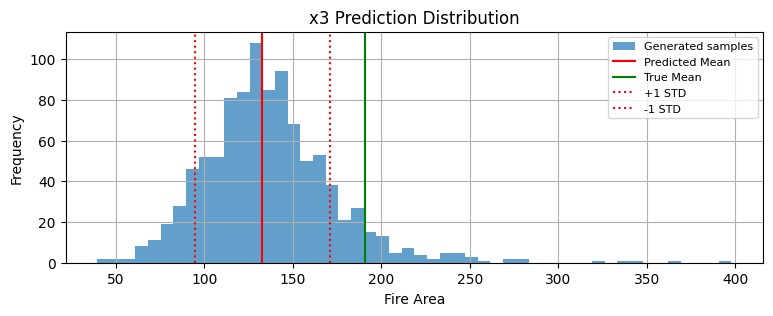

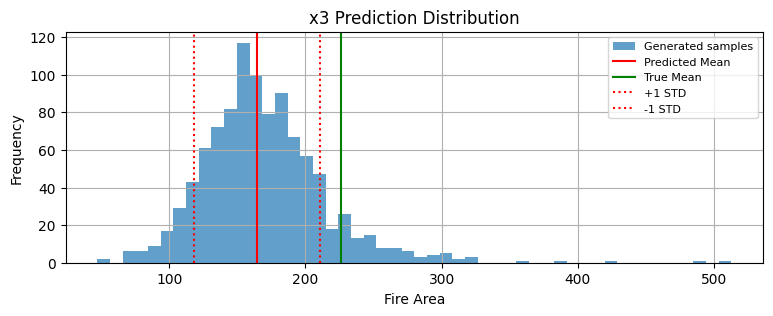

In [70]:
for i in range (3, 14):
    plt.figure(figsize=(9,3))
    plt.title('x3 Prediction Distribution')
    plt.hist(dist_x3_orig[i], bins=50, alpha=0.7, label='Generated samples') 
    plt.xlabel('Fire Area')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.axvline(pred[i], color='red', label='Predicted Mean')
    plt.axvline(real[i], color='green', label='True Mean')
    plt.axvline(pred[i]+std_x3[i], color='red', label='+1 STD', linestyle=':')
    plt.axvline(pred[i]-std_x3[i], color='red', label='-1 STD', linestyle=':')
    plt.legend(fontsize='8')
    plt.show()